In [1]:
import os
import shutil
import random
from pathlib import Path
from collections import Counter, defaultdict

import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from ultralytics import YOLO

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
# DEVICE = "cpu"
print("Using device:", DEVICE)

Using device: mps


In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download("shlokraval/ppe-dataset-yolov8")
dataset_path = Path(dataset_path)

print("Dataset path:", dataset_path)
print("Top-level contents:", os.listdir(dataset_path))

Dataset path: /Users/meghasuhanth/.cache/kagglehub/datasets/shlokraval/ppe-dataset-yolov8/versions/1
Top-level contents: ['README.roboflow.txt', 'valid', 'README.dataset.txt', 'test', 'data.yaml', 'train']


In [3]:
yaml_files = list(dataset_path.rglob("*.yaml"))
print("YAML files found:")
for y in yaml_files:
    print(" -", y)

assert len(yaml_files) > 0, "No YAML file found."

data_yaml_path = yaml_files[0]
print("\nUsing YAML:", data_yaml_path)

with open(data_yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

names = data_cfg.get("names", {})
if isinstance(names, list):
    class_id_to_name = {i: n for i, n in enumerate(names)}
elif isinstance(names, dict):
    class_id_to_name = {int(k): v for k, v in names.items()}
else:
    raise ValueError("Unsupported class mapping format.")

print("\nClass mapping:")
for k, v in class_id_to_name.items():
    print(k, "->", v)

YAML files found:
 - /Users/meghasuhanth/.cache/kagglehub/datasets/shlokraval/ppe-dataset-yolov8/versions/1/data.yaml

Using YAML: /Users/meghasuhanth/.cache/kagglehub/datasets/shlokraval/ppe-dataset-yolov8/versions/1/data.yaml

Class mapping:
0 -> Fall-Detected
1 -> Gloves
2 -> Goggles
3 -> Hardhat
4 -> Ladder
5 -> Mask
6 -> NO-Gloves
7 -> NO-Goggles
8 -> NO-Hardhat
9 -> NO-Mask
10 -> NO-Safety Vest
11 -> Person
12 -> Safety Cone
13 -> Safety Vest


In [4]:
#Selecting 5 target classes
def normalize_name(x):
    return str(x).strip().lower().replace("-", " ").replace("_", " ")

target_keywords = {
    "person": ["person", "worker", "man", "woman", "human", "people"],
    "helmet": ["helmet", "hardhat", "hard hat", "hat"],
    "vest": ["vest", "safety vest", "reflective vest", "jacket"],
    "gloves": ["glove", "gloves", "hand gloves"],
    "goggles": ["goggle", "goggles", "glasses", "safety glasses", "eye protection"]
}

selected_original_ids = {}

for cid, cname in class_id_to_name.items():
    cname_norm = normalize_name(cname)
    for target_class, keywords in target_keywords.items():
        if any(k in cname_norm for k in keywords):
            if target_class not in selected_original_ids:
                selected_original_ids[target_class] = cid

print("Selected original class IDs:")
print(selected_original_ids)

required = ["person", "helmet", "vest", "gloves", "goggles"]
missing = [c for c in required if c not in selected_original_ids]
if missing:
    raise ValueError(
        f"Could not find required classes: {missing}\n"
        "Please inspect the printed dataset class mapping and adjust target keywords."
    )

old_to_new = {
    selected_original_ids["person"]: 0,
    selected_original_ids["helmet"]: 1,
    selected_original_ids["vest"]: 2,
    selected_original_ids["gloves"]: 3,
    selected_original_ids["goggles"]: 4
}

new_names = {
    0: "person",
    1: "helmet",
    2: "vest",
    3: "gloves",
    4: "goggles"
}

print("Old -> New mapping:", old_to_new)
print("New names:", new_names)

Selected original class IDs:
{'gloves': 1, 'goggles': 2, 'helmet': 3, 'vest': 10, 'person': 11}
Old -> New mapping: {11: 0, 3: 1, 10: 2, 1: 3, 2: 4}
New names: {0: 'person', 1: 'helmet', 2: 'vest', 3: 'gloves', 4: 'goggles'}


In [5]:
#Creating filtered local 5-class dataset
subset_root = Path("filtered_ppe_5class")
subset_root.mkdir(exist_ok=True)

splits_to_try = {
    "train": ["train"],
    "val": ["valid", "val"],
    "test": ["test"]
}

max_images_per_split = {
    "train": 5000,
    "val": 1000,
    "test": 1000
}

def find_existing_split(base_path, candidates):
    for c in candidates:
        img_dir = base_path / c / "images"
        lbl_dir = base_path / c / "labels"
        if img_dir.exists() and lbl_dir.exists():
            return c, img_dir, lbl_dir
    return None, None, None

summary = {}

for target_split, candidate_names in splits_to_try.items():
    src_split_name, src_img_dir, src_lbl_dir = find_existing_split(dataset_path, candidate_names)
    if src_split_name is None:
        print(f"Skipping missing split: {target_split}")
        continue

    dst_img_dir = subset_root / target_split / "images"
    dst_lbl_dir = subset_root / target_split / "labels"
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    image_files = [
        p for p in src_img_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]
    random.Random(SEED).shuffle(image_files)

    kept = 0
    for img_path in image_files:
        if kept >= max_images_per_split[target_split]:
            break

        label_path = src_lbl_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue

        filtered_lines = []
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id = int(float(parts[0]))
                if cls_id in old_to_new:
                    new_cls = old_to_new[cls_id]
                    filtered_lines.append(
                        f"{new_cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}"
                    )

        if len(filtered_lines) == 0:
            continue

        shutil.copy2(img_path, dst_img_dir / img_path.name)
        with open(dst_lbl_dir / f"{img_path.stem}.txt", "w") as f:
            f.write("\n".join(filtered_lines) + "\n")

        kept += 1

    summary[target_split] = kept

print("Filtered dataset summary:", summary)

Filtered dataset summary: {'train': 5000, 'val': 1000, 'test': 1000}


In [6]:
#Creating local data.yaml
subset_yaml = {
    "path": str(subset_root.resolve()),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": new_names
}

yaml_path = subset_root / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(subset_yaml, f, sort_keys=False)

print("Saved data.yaml to:", yaml_path)

Saved data.yaml to: filtered_ppe_5class/data.yaml


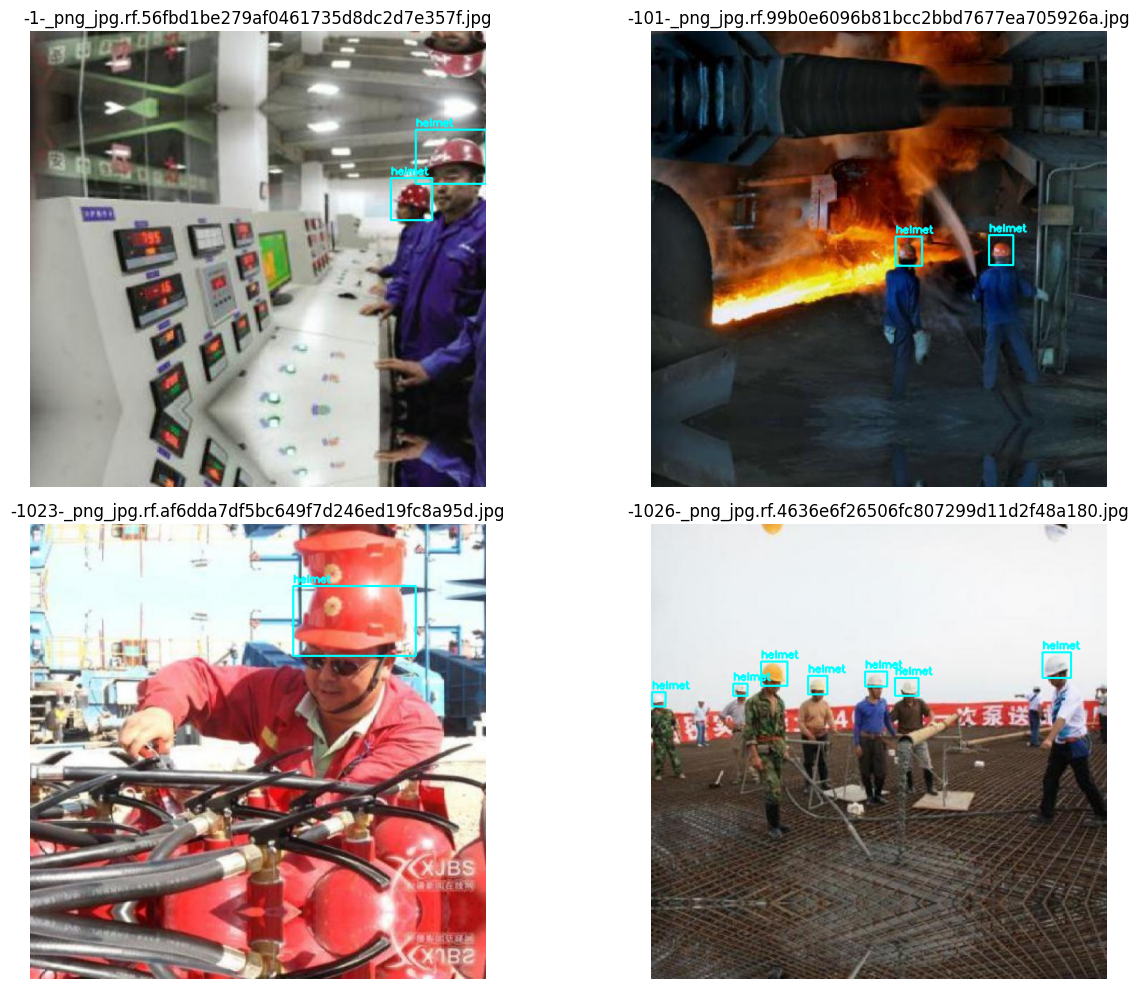

In [7]:
#Few samples
def load_yolo_boxes(label_file, image_shape):
    h, w = image_shape[:2]
    boxes = []
    if not os.path.exists(label_file):
        return boxes

    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls_id, xc, yc, bw, bh = map(float, parts)
            cls_id = int(cls_id)

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            boxes.append((cls_id, x1, y1, x2, y2))
    return boxes

sample_train_dir = subset_root / "train" / "images"
sample_images = sorted(list(sample_train_dir.glob("*")))[:4]

plt.figure(figsize=(14, 10))
for i, img_path in enumerate(sample_images, 1):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    label_path = subset_root / "train" / "labels" / f"{img_path.stem}.txt"
    boxes = load_yolo_boxes(str(label_path), img.shape)

    for cls_id, x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 255), 2)
        cv2.putText(img, new_names[cls_id], (x1, max(15, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

##  **Loading Trained Model from Colab**

In [8]:
from pathlib import Path
from ultralytics import YOLO

best_detector_path = Path("models/best.pt")
print("Best detector path exists:", best_detector_path.exists())

detector = YOLO(str(best_detector_path))

Best detector path exists: True


In [9]:
#Validating Detector
val_metrics = detector.val(
    data=str(yaml_path),
    split="val",
    imgsz=640,
    batch=8,
    device=DEVICE
)

print(val_metrics)

Ultralytics 8.4.37 🚀 Python-3.10.20 torch-2.11.0 MPS (Apple M4)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 329.5±81.5 MB/s, size: 57.7 KB)
val: Scanning /Users/meghasuhanth/Documents/ADL Project/Hazard Risk/notebooks/filtered_ppe_5class/val/labels.cache... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 161.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 3.2it/s 39.1s0.3ss
                   all       1000       2432      0.733      0.794      0.777      0.475
                person         40         60      0.854      0.875       0.92      0.725
                helmet        694       1983      0.853      0.877      0.895      0.505
                  vest         30         47      0.257      0.298      0.186     0.0951
                gloves         81        172       0.83      0.936      0.917   

In [10]:
#Risk label logic from GT counts
RISK_NAME_TO_ID = {"Low": 0, "Medium": 1, "High": 2}
RISK_ID_TO_NAME = {v: k for k, v in RISK_NAME_TO_ID.items()}

def gt_counts_from_label_file(label_file):
    counts = Counter()
    if not os.path.exists(label_file):
        return {
            "person_count": 0,
            "helmet_count": 0,
            "vest_count": 0,
            "gloves_count": 0,
            "goggles_count": 0
        }

    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id = int(float(parts[0]))
            if cls_id == 0:
                counts["person_count"] += 1
            elif cls_id == 1:
                counts["helmet_count"] += 1
            elif cls_id == 2:
                counts["vest_count"] += 1
            elif cls_id == 3:
                counts["gloves_count"] += 1
            elif cls_id == 4:
                counts["goggles_count"] += 1

    return {
        "person_count": counts["person_count"],
        "helmet_count": counts["helmet_count"],
        "vest_count": counts["vest_count"],
        "gloves_count": counts["gloves_count"],
        "goggles_count": counts["goggles_count"]
    }

def safe_ratio(count, person_count):
    if person_count == 0:
        return 0.0
    return min(count / person_count, 1.0)

def risk_from_gt_counts(stats):
    p = stats["person_count"]
    if p == 0:
        return RISK_NAME_TO_ID["Low"]

    helmet_ratio = safe_ratio(stats["helmet_count"], p)
    vest_ratio = safe_ratio(stats["vest_count"], p)
    gloves_ratio = safe_ratio(stats["gloves_count"], p)
    goggles_ratio = safe_ratio(stats["goggles_count"], p)

    weighted_score = (
        0.35 * helmet_ratio +
        0.30 * vest_ratio +
        0.20 * gloves_ratio +
        0.15 * goggles_ratio
    )

    critical_fail = (helmet_ratio < 0.5) or (vest_ratio < 0.5)
    severe_multi_fail = sum(r < 0.5 for r in [helmet_ratio, vest_ratio, gloves_ratio, goggles_ratio]) >= 2

    if weighted_score >= 0.90 and helmet_ratio >= 0.90 and vest_ratio >= 0.90:
        return RISK_NAME_TO_ID["Low"]
    elif critical_fail or severe_multi_fail or weighted_score < 0.65:
        return RISK_NAME_TO_ID["High"]
    else:
        return RISK_NAME_TO_ID["Medium"]

In [11]:
#Extracting structured features from detector predictions
def features_from_prediction_result(result, conf_threshold=0.25):
    if result.boxes is None or len(result.boxes) == 0:
        return {
            "person_count": 0,
            "helmet_count": 0,
            "vest_count": 0,
            "gloves_count": 0,
            "goggles_count": 0,
            "helmet_ratio": 0.0,
            "vest_ratio": 0.0,
            "gloves_ratio": 0.0,
            "goggles_ratio": 0.0,
            "missing_helmet_count": 0,
            "missing_vest_count": 0,
            "missing_gloves_count": 0,
            "missing_goggles_count": 0,
            "weighted_score": 0.0,
            "person_conf_mean": 0.0,
            "helmet_conf_mean": 0.0,
            "vest_conf_mean": 0.0,
            "gloves_conf_mean": 0.0,
            "goggles_conf_mean": 0.0
        }

    cls_ids = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    person_mask = cls_ids == 0
    helmet_mask = cls_ids == 1
    vest_mask = cls_ids == 2
    gloves_mask = cls_ids == 3
    goggles_mask = cls_ids == 4

    person_count = int(person_mask.sum())
    helmet_count = int(helmet_mask.sum())
    vest_count = int(vest_mask.sum())
    gloves_count = int(gloves_mask.sum())
    goggles_count = int(goggles_mask.sum())

    helmet_ratio = safe_ratio(helmet_count, person_count)
    vest_ratio = safe_ratio(vest_count, person_count)
    gloves_ratio = safe_ratio(gloves_count, person_count)
    goggles_ratio = safe_ratio(goggles_count, person_count)

    weighted_score = (
        0.35 * helmet_ratio +
        0.30 * vest_ratio +
        0.20 * gloves_ratio +
        0.15 * goggles_ratio
    )

    return {
        "person_count": person_count,
        "helmet_count": helmet_count,
        "vest_count": vest_count,
        "gloves_count": gloves_count,
        "goggles_count": goggles_count,
        "helmet_ratio": helmet_ratio,
        "vest_ratio": vest_ratio,
        "gloves_ratio": gloves_ratio,
        "goggles_ratio": goggles_ratio,
        "missing_helmet_count": max(person_count - helmet_count, 0),
        "missing_vest_count": max(person_count - vest_count, 0),
        "missing_gloves_count": max(person_count - gloves_count, 0),
        "missing_goggles_count": max(person_count - goggles_count, 0),
        "weighted_score": weighted_score,
        "person_conf_mean": float(confs[person_mask].mean()) if person_mask.sum() else 0.0,
        "helmet_conf_mean": float(confs[helmet_mask].mean()) if helmet_mask.sum() else 0.0,
        "vest_conf_mean": float(confs[vest_mask].mean()) if vest_mask.sum() else 0.0,
        "gloves_conf_mean": float(confs[gloves_mask].mean()) if gloves_mask.sum() else 0.0,
        "goggles_conf_mean": float(confs[goggles_mask].mean()) if goggles_mask.sum() else 0.0
    }

In [12]:
#Building the image-level dataframe
import gc
import math

def chunk_list(items, chunk_size):
    for i in range(0, len(items), chunk_size):
        yield items[i:i + chunk_size]

def collect_split_dataframe(split_name, imgsz=512, batch_size=None, inference_device=None):
    image_dir = subset_root / split_name / "images"
    label_dir = subset_root / split_name / "labels"
    image_paths = sorted([
        p for p in image_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])

    if inference_device is None:
        inference_device = DEVICE

    if batch_size is None:
        batch_size = 8 if inference_device == "mps" else 4

    rows = []

    print(f"\nProcessing split: {split_name}")
    print(f"Number of images: {len(image_paths)}")
    print(f"Using device: {inference_device}, imgsz={imgsz}, batch_size={batch_size}")

    for batch_idx, batch_paths in enumerate(chunk_list(image_paths, batch_size), 1):
        batch_sources = [str(p) for p in batch_paths]

        results = detector.predict(
            source=batch_sources,
            conf=0.25,
            imgsz=imgsz,
            device=inference_device,
            verbose=False,
            stream=False   # batch returns a list directly
        )

        for img_path, result in zip(batch_paths, results):
            gt_stats = gt_counts_from_label_file(str(label_dir / f"{img_path.stem}.txt"))
            risk_label = risk_from_gt_counts(gt_stats)

            pred_feats = features_from_prediction_result(result, conf_threshold=0.25)

            row = {
                "split": split_name,
                "image_path": str(img_path),
                "risk_label": risk_label,
                "risk_name": RISK_ID_TO_NAME[risk_label],
                **pred_feats
            }
            rows.append(row)

        if batch_idx % 20 == 0:
            print(f"Processed {min(batch_idx * batch_size, len(image_paths))}/{len(image_paths)} images")

        # clear memory between batches
        gc.collect()
        if torch.backends.mps.is_available():
            try:
                torch.mps.empty_cache()
            except:
                pass

    return pd.DataFrame(rows)

df_train = collect_split_dataframe("train", imgsz=512, batch_size=4, inference_device="mps")
df_val   = collect_split_dataframe("val", imgsz=512, batch_size=4, inference_device="mps")
df_test  = collect_split_dataframe("test", imgsz=512, batch_size=4, inference_device="mps")

risk_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

print("Train label distribution:")
print(df_train["risk_name"].value_counts())

print("\nValidation label distribution:")
print(df_val["risk_name"].value_counts())

print("\nTest label distribution:")
print(df_test["risk_name"].value_counts())


Processing split: train
Number of images: 5000
Using device: mps, imgsz=512, batch_size=4
Processed 80/5000 images
Processed 160/5000 images
Processed 240/5000 images
Processed 320/5000 images
Processed 400/5000 images
Processed 480/5000 images
Processed 560/5000 images
Processed 640/5000 images
Processed 720/5000 images
Processed 800/5000 images
Processed 880/5000 images
Processed 960/5000 images
Processed 1040/5000 images
Processed 1120/5000 images
Processed 1200/5000 images
Processed 1280/5000 images
Processed 1360/5000 images
Processed 1440/5000 images
Processed 1520/5000 images
Processed 1600/5000 images
Processed 1680/5000 images
Processed 1760/5000 images
Processed 1840/5000 images
Processed 1920/5000 images
Processed 2000/5000 images
Processed 2080/5000 images
Processed 2160/5000 images
Processed 2240/5000 images
Processed 2320/5000 images
Processed 2400/5000 images
Processed 2480/5000 images
Processed 2560/5000 images
Processed 2640/5000 images
Processed 2720/5000 images
Proc

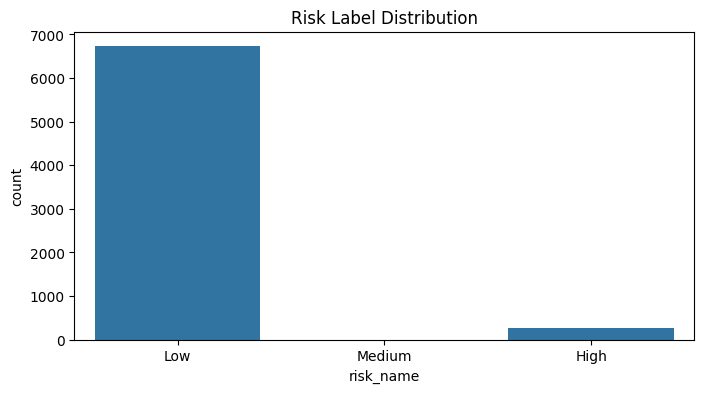

In [13]:
plt.figure(figsize=(8, 4))
sns.countplot(data=risk_df, x="risk_name", order=["Low", "Medium", "High"])
plt.title("Risk Label Distribution")
plt.show()

In [14]:
# Training the final risk classifier
feature_cols = [
    "person_count",
    "helmet_count",
    "vest_count",
    "gloves_count",
    "goggles_count",
    "helmet_ratio",
    "vest_ratio",
    "gloves_ratio",
    "goggles_ratio",
    "missing_helmet_count",
    "missing_vest_count",
    "missing_gloves_count",
    "missing_goggles_count",
    "weighted_score",
    "person_conf_mean",
    "helmet_conf_mean",
    "vest_conf_mean",
    "gloves_conf_mean",
    "goggles_conf_mean"
]

X_train = df_train[feature_cols]
y_train = df_train["risk_label"]

X_val = df_val[feature_cols]
y_val = df_val["risk_label"]

X_test = df_test[feature_cols]
y_test = df_test["risk_label"]

print("Unique classes in y_train:", sorted(y_train.unique().tolist()))
print("Train counts:\n", y_train.value_counts().sort_index())

risk_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=SEED
    ))
])

risk_clf.fit(X_train, y_train)

val_pred = risk_clf.predict(X_val)
test_pred = risk_clf.predict(X_test)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation Macro F1:", f1_score(y_val, val_pred, average="macro"))

print("\nTest Accuracy:", accuracy_score(y_test, test_pred))
print("Test Macro F1:", f1_score(y_test, test_pred, average="macro"))

Unique classes in y_train: [0, 2]
Train counts:
 risk_label
0    4803
2     197
Name: count, dtype: int64
Validation Accuracy: 0.976
Validation Macro F1: 0.8760304964978616

Test Accuracy: 0.976
Test Macro F1: 0.8660445178718938


/opt/anaconda3/envs/adlproject/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/adlproject/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/adlproject/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/adlproject/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/anaconda3/envs/adlproject/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

In [15]:
#Class-wise Evaluation
labels = [0, 1, 2]

print("Validation classification report:")
print(classification_report(
    y_val,
    val_pred,
    labels=labels,
    target_names=["Low", "Medium", "High"],
    zero_division=0
))

print("\nTest classification report:")
print(classification_report(
    y_test,
    test_pred,
    labels=labels,
    target_names=["Low", "Medium", "High"],
    zero_division=0
))

if 2 in np.unique(y_test):
    high_risk_recall = recall_score(y_test, test_pred, labels=[2], average=None)[0]
else:
    high_risk_recall = 0.0

print("\nHigh-risk recall on test set:", high_risk_recall)

Validation classification report:
              precision    recall  f1-score   support

         Low       1.00      0.98      0.99       960
      Medium       0.00      0.00      0.00         0
        High       0.63      0.97      0.76        40

    accuracy                           0.98      1000
   macro avg       0.54      0.65      0.58      1000
weighted avg       0.98      0.98      0.98      1000


Test classification report:
              precision    recall  f1-score   support

         Low       1.00      0.98      0.99       965
      Medium       0.00      0.00      0.00         0
        High       0.59      1.00      0.74        35

    accuracy                           0.98      1000
   macro avg       0.53      0.66      0.58      1000
weighted avg       0.99      0.98      0.98      1000


High-risk recall on test set: 1.0


In [26]:
#Metrics Summary
import json

results_dir = Path("/Users/meghasuhanth/Documents/ADL Project/Hazard Risk/results")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_summary = {
    "validation_accuracy": float(accuracy_score(y_val, val_pred)),
    "validation_macro_f1": float(f1_score(y_val, val_pred, average="macro")),
    "test_accuracy": float(accuracy_score(y_test, test_pred)),
    "test_macro_f1": float(f1_score(y_test, test_pred, average="macro")),
    "test_high_risk_recall": float(
        recall_score(y_test, test_pred, labels=[2], average=None)[0]
        if 2 in set(y_test) else 0.0
    )
}

metrics_path = results_dir / "metrics_summary.json"

with open(metrics_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Saved metrics summary to:", metrics_path)
print(metrics_summary)

Saved metrics summary to: /Users/meghasuhanth/Documents/ADL Project/Hazard Risk/results/metrics_summary.json
{'validation_accuracy': 0.976, 'validation_macro_f1': 0.8760304964978616, 'test_accuracy': 0.976, 'test_macro_f1': 0.8660445178718938, 'test_high_risk_recall': 1.0}


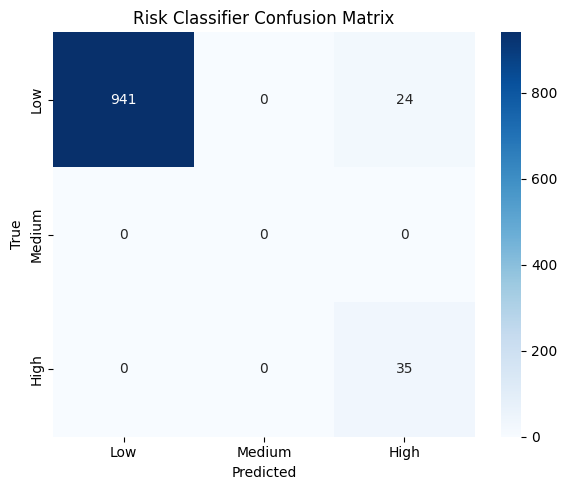

Saved confusion matrix to: /Users/meghasuhanth/Documents/ADL Project/Hazard Risk/results/confusion_matrix.png


In [29]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

results_dir = Path("/Users/meghasuhanth/Documents/ADL Project/Hazard Risk/results")
results_dir.mkdir(parents=True, exist_ok=True)

cm_path = results_dir / "confusion_matrix.png"

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Risk Classifier Confusion Matrix")
plt.tight_layout()
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:", cm_path)

In [23]:
#Explanation Function
def risk_explanation_from_features(feats, predicted_risk_id):
    reasons = []

    if feats["missing_helmet_count"] > 0:
        reasons.append("helmet shortage detected")
    if feats["missing_vest_count"] > 0:
        reasons.append("vest shortage detected")
    if feats["missing_gloves_count"] > 0:
        reasons.append("glove shortage detected")
    if feats["missing_goggles_count"] > 0:
        reasons.append("goggle shortage detected")

    if len(reasons) == 0:
        return f"{RISK_ID_TO_NAME[predicted_risk_id]} risk: detected workers appear compliant with selected PPE."

    return f"{RISK_ID_TO_NAME[predicted_risk_id]} risk: " + ", ".join(reasons) + "."

In [17]:
# Feature importance analysis
import pandas as pd
import numpy as np

log_reg_model = risk_clf.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": log_reg_model.coef_[0] if log_reg_model.coef_.shape[0] == 1 else log_reg_model.coef_.mean(axis=0)
})

coef_df["absolute_importance"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("absolute_importance", ascending=False)

coef_df

,feature,coefficient,absolute_importance
15,helmet_conf_mean,-1.939306,1.939306
9,missing_helmet_count,1.877237,1.877237
1,helmet_count,-1.608540,1.608540
18,goggles_conf_mean,-1.402958,1.402958
17,gloves_conf_mean,-1.297472,1.297472
4,goggles_count,-1.235275,1.235275
3,gloves_count,-0.860952,0.860952
16,vest_conf_mean,-0.792428,0.792428
2,vest_count,-0.434595,0.434595
14,person_conf_mean,0.259291,0.259291


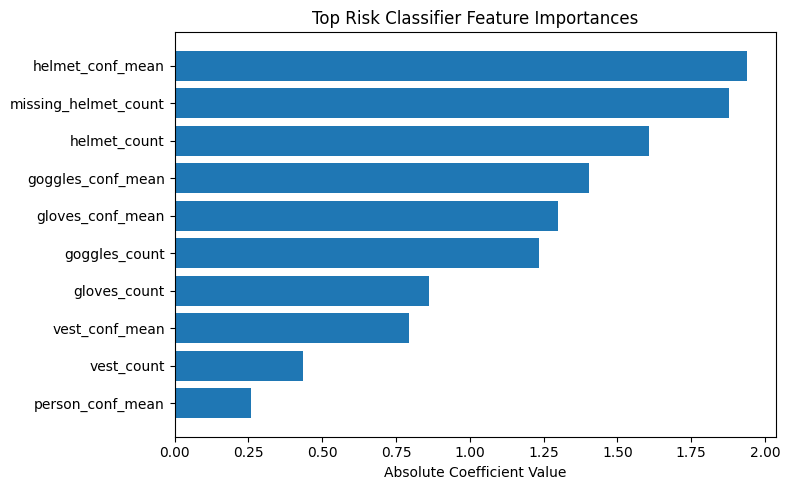

In [ ]:
import matplotlib.pyplot as plt

top_features = coef_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["absolute_importance"])
plt.xlabel("Absolute Coefficient Value")
plt.title("Top Risk Classifier Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("/Users/meghasuhanth/Documents/ADL Project/Hazard Risk/results/feature_importance.png", bbox_inches="tight")
plt.show()

In [20]:
#Helper for one-row feature input
def make_feature_frame(feats, feature_cols):
    return pd.DataFrame([[feats[col] for col in feature_cols]], columns=feature_cols)

In [21]:
#Visual grounding
def draw_risk_grounding(img_bgr, result, predicted_risk_id):
    img = img_bgr.copy()

    if result.boxes is None or len(result.boxes) == 0:
        return img

    xyxy = result.boxes.xyxy.cpu().numpy().astype(int)
    cls_ids = result.boxes.cls.cpu().numpy().astype(int)
    confs = result.boxes.conf.cpu().numpy()

    class_names = {
        0: "person",
        1: "helmet",
        2: "vest",
        3: "gloves",
        4: "goggles"
    }

    for box, cls_id, conf in zip(xyxy, cls_ids, confs):
        x1, y1, x2, y2 = box.tolist()

        if cls_id == 0:
            color = (0, 255, 0) if predicted_risk_id == 0 else (0, 165, 255) if predicted_risk_id == 1 else (0, 0, 255)
        else:
            color = (255, 255, 0)

        label = f"{class_names.get(cls_id, 'obj')} {conf:.2f}"

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            img,
            label,
            (x1, max(18, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

    footer = f"Predicted Risk: {RISK_ID_TO_NAME[predicted_risk_id]}"
    cv2.putText(img, footer, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 3)
    cv2.putText(img, footer, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 1)

    return img

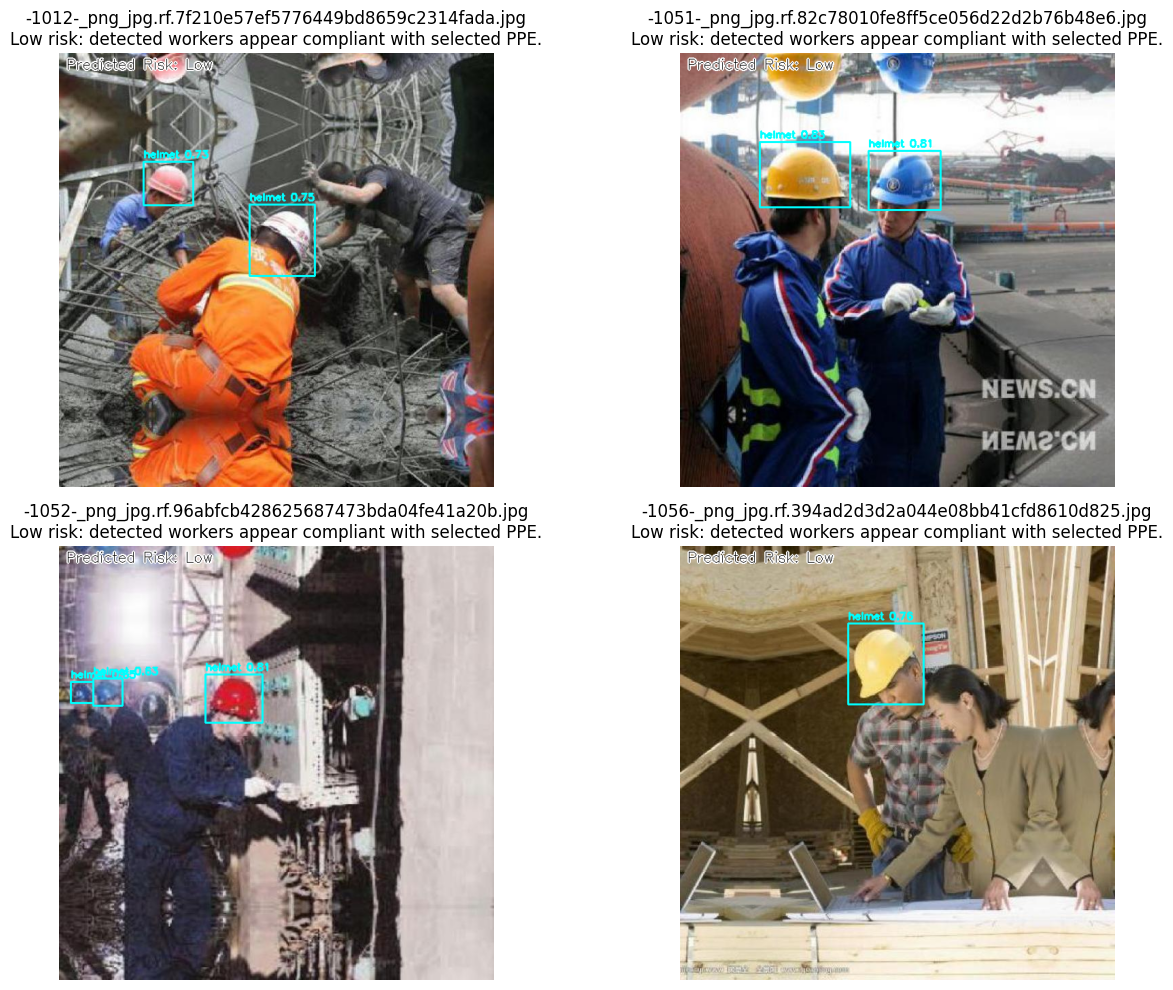

In [24]:
#Sample Predictions
demo_images = sorted((subset_root / "test" / "images").glob("*"))[:4]

plt.figure(figsize=(14, 10))

for i, img_path in enumerate(demo_images, 1):
    pred_result = detector.predict(
        source=str(img_path),
        conf=0.25,
        imgsz=640,
        device=DEVICE,
        verbose=False
    )[0]

    feats = features_from_prediction_result(pred_result, conf_threshold=0.25)
    single_input = make_feature_frame(feats, feature_cols)
    pred_risk = risk_clf.predict(single_input)[0]
    explanation = risk_explanation_from_features(feats, pred_risk)

    img_bgr = cv2.imread(str(img_path))
    grounded = draw_risk_grounding(img_bgr, pred_result, pred_risk)
    grounded_rgb = cv2.cvtColor(grounded, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i)
    plt.imshow(grounded_rgb)
    plt.title(f"{img_path.name}\n{explanation}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
#Save Classifier

import joblib
from pathlib import Path
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

joblib.dump(risk_clf, models_dir / "risk_classifier.pkl")
print("Saved classifier to:", models_dir / "risk_classifier.pkl")

Saved classifier to: models/risk_classifier.pkl


## Final Reusable prediction function

In [26]:
def predict_image_risk(image_path, detector_model, classifier_model, feature_cols, device=DEVICE, conf=0.25):
    result = detector_model.predict(
        source=str(image_path),
        conf=conf,
        imgsz=640,
        device=device,
        verbose=False
    )[0]

    feats = features_from_prediction_result(result, conf_threshold=conf)
    single_input = make_feature_frame(feats, feature_cols)
    pred_risk = classifier_model.predict(single_input)[0]
    explanation = risk_explanation_from_features(feats, pred_risk)

    img_bgr = cv2.imread(str(image_path))
    grounded_img = draw_risk_grounding(img_bgr, result, pred_risk)

    return {
        "risk_id": int(pred_risk),
        "risk_name": RISK_ID_TO_NAME[int(pred_risk)],
        "features": feats,
        "explanation": explanation,
        "grounded_bgr": grounded_img
    }

Predicted Risk: Low
Explanation: Low risk: detected workers appear compliant with selected PPE.
Features: {'person_count': 0, 'helmet_count': 2, 'vest_count': 0, 'gloves_count': 0, 'goggles_count': 0, 'helmet_ratio': 0.0, 'vest_ratio': 0.0, 'gloves_ratio': 0.0, 'goggles_ratio': 0.0, 'missing_helmet_count': 0, 'missing_vest_count': 0, 'missing_gloves_count': 0, 'missing_goggles_count': 0, 'weighted_score': 0.0, 'person_conf_mean': 0.0, 'helmet_conf_mean': 0.7429852485656738, 'vest_conf_mean': 0.0, 'gloves_conf_mean': 0.0, 'goggles_conf_mean': 0.0}


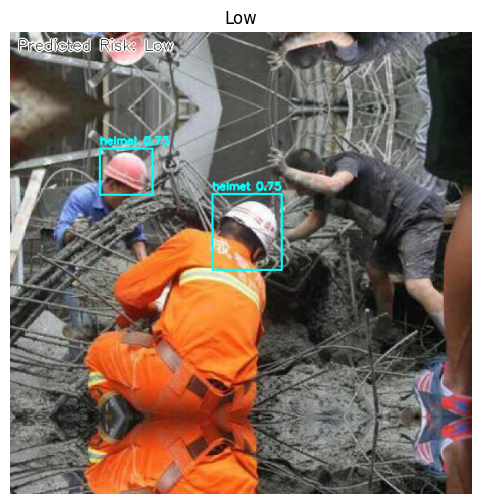

In [27]:
#Quick Final Test
test_example = sorted((subset_root / "test" / "images").glob("*"))[0]

output = predict_image_risk(
    image_path=test_example,
    detector_model=detector,
    classifier_model=risk_clf,
    feature_cols=feature_cols,
    device=DEVICE,
    conf=0.25
)

print("Predicted Risk:", output["risk_name"])
print("Explanation:", output["explanation"])
print("Features:", output["features"])

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(output["grounded_bgr"], cv2.COLOR_BGR2RGB))
plt.title(output["risk_name"])
plt.axis("off")
plt.show()